<a href="https://colab.research.google.com/github/keshavsharma0925/blood-cell-classification/blob/main/blood_cell_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Set Up

In [ ]:
# APS360 Progress Report Notebook
# Project: White Blood Cell Classification using Deep Learning
# Author: Keshav Sharma

!pip -q install kaggle

import os
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


Downloading Kaggle Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

import zipfile
import os

zip_name = list(uploaded.keys())[0]
print("Uploaded file:", zip_name)

os.makedirs("/content/data", exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

print("Dataset unzipped to /content/data")

Saving archive.zip to archive.zip
Uploaded file: archive.zip
Dataset unzipped to /content/data


Finding Image Files and Labels

In [ ]:
root = Path("/content/data")

class_names = ["EOSINOPHIL", "LYMPHOCYTE", "MONOCYTE", "NEUTROPHIL"]
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

image_extensions = {".jpg", ".jpeg", ".png"}

records = []

for path in root.rglob("*"):
    if path.suffix.lower() in image_extensions:
        path_parts = [part.upper() for part in path.parts]

        label = None
        for class_name in class_names:
            if class_name in path_parts:
                label = class_name
                break

        if label is not None:
            records.append({
                "path": str(path),
                "label": label
            })

df = pd.DataFrame(records)

print("Total raw images found:", len(df))
print("\nRaw class counts:")
display(df["label"].value_counts().loc[class_names])

Total raw images found: 12515

Raw class counts:


,count
label,
EOSINOPHIL,3133
LYMPHOCYTE,3109
MONOCYTE,3102
NEUTROPHIL,3171


Data Cleaning

In [ ]:
def get_file_hash(file_path):
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

clean_records = []
bad_files = []
seen_hashes = set()
duplicate_count = 0

for _, row in df.iterrows():
    image_path = row["path"]
    label = row["label"]

    try:
        with Image.open(image_path) as img:
            img.verify()

        image_hash = get_file_hash(image_path)

        if image_hash not in seen_hashes:
            seen_hashes.add(image_hash)
            clean_records.append({
                "path": image_path,
                "label": label
            })
        else:
            duplicate_count += 1

    except:
        bad_files.append(image_path)

clean_df = pd.DataFrame(clean_records)

print("Unreadable files removed:", len(bad_files))
print("Duplicate files removed:", duplicate_count)
print("Clean images kept:", len(clean_df))

print("\nClean class counts:")
display(clean_df["label"].value_counts().loc[class_names])

clean_df.to_csv("cleaned_image_index.csv", index=False)

Unreadable files removed: 0
Duplicate files removed: 2
Clean images kept: 12513

Clean class counts:


,count
label,
EOSINOPHIL,3131
LYMPHOCYTE,3109
MONOCYTE,3102
NEUTROPHIL,3171


Train/Validation/Test Split

In [ ]:
train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.30,
    stratify=clean_df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

split_summary = pd.DataFrame({
    "Train": train_df["label"].value_counts(),
    "Validation": val_df["label"].value_counts(),
    "Test": test_df["label"].value_counts()
}).loc[class_names]

split_summary["Total"] = split_summary.sum(axis=1)

display(split_summary)

split_summary.to_csv("split_summary.csv")

,Train,Validation,Test,Total
label,,,,
EOSINOPHIL,2192,469,470,3131
LYMPHOCYTE,2176,467,466,3109
MONOCYTE,2171,466,465,3102
NEUTROPHIL,2220,475,476,3171


Distribution Plot

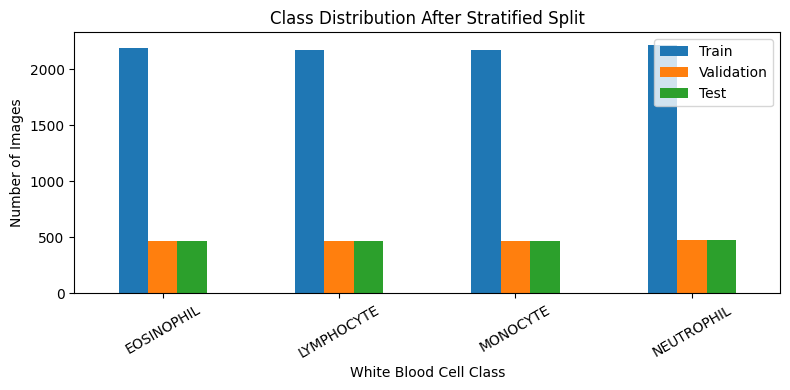

In [ ]:
split_summary[["Train", "Validation", "Test"]].plot(kind="bar", figsize=(8, 4))

plt.title("Class Distribution After Stratified Split")
plt.xlabel("White Blood Cell Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300)
plt.show()

Training Examples

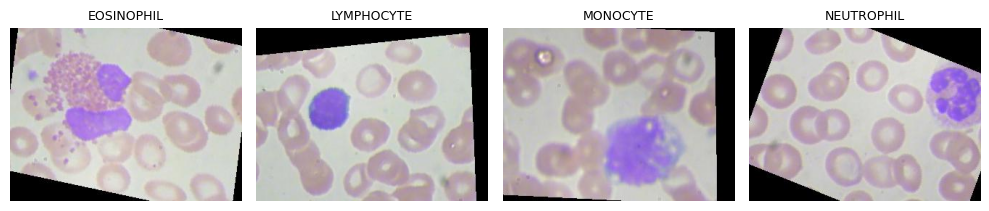

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(10, 3))

for ax, class_name in zip(axes, class_names):
    sample_row = train_df[train_df["label"] == class_name].sample(1, random_state=SEED).iloc[0]
    image = Image.open(sample_row["path"]).convert("RGB")

    ax.imshow(image)
    ax.set_title(class_name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("cleaned_training_examples.png", dpi=300)
plt.show()

PyTorch Dataset Class

In [ ]:
IMG_SIZE = 64
BATCH_SIZE = 64

baseline_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

cnn_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

class BloodCellDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        image_path = self.dataframe.loc[index, "path"]
        label_name = self.dataframe.loc[index, "label"]

        image = Image.open(image_path).convert("RGB")
        label = class_to_idx[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label

Data Loaders

In [ ]:
# Baseline ANN data loaders
baseline_train_dataset = BloodCellDataset(train_df, transform=baseline_transform)
baseline_val_dataset = BloodCellDataset(val_df, transform=eval_transform)

baseline_train_loader = DataLoader(
    baseline_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

baseline_val_loader = DataLoader(
    baseline_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# CNN data loaders
cnn_train_dataset = BloodCellDataset(train_df, transform=cnn_train_transform)
cnn_val_dataset = BloodCellDataset(val_df, transform=eval_transform)
test_dataset = BloodCellDataset(test_df, transform=eval_transform)

cnn_train_loader = DataLoader(
    cnn_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

cnn_val_loader = DataLoader(
    cnn_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Baseline train batches:", len(baseline_train_loader))
print("Baseline validation batches:", len(baseline_val_loader))
print("CNN train batches:", len(cnn_train_loader))
print("CNN validation batches:", len(cnn_val_loader))

Baseline train batches: 137
Baseline validation batches: 30
CNN train batches: 137
CNN validation batches: 30


Baseline ANN model

In [ ]:
class BaselineANN(nn.Module):
    def __init__(self, num_classes=4):
        super(BaselineANN, self).__init__()

        self.layer1 = nn.Linear(3 * IMG_SIZE * IMG_SIZE, 128)
        self.dropout = nn.Dropout(p=0.2)
        self.layer2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.layer2(x)
        return x

baseline_model = BaselineANN(num_classes=4).to(device)

baseline_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)

print(baseline_model)
print("Trainable parameters:", baseline_params)

BaselineANN(
  (layer1): Linear(in_features=12288, out_features=128, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (layer2): Linear(in_features=128, out_features=4, bias=True)
)
Trainable parameters: 1573508


Training and Evaluation

In [ ]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def evaluate_model(model, dataloader):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy, all_predictions, all_labels


def train_model(model, train_loader, val_loader, epochs, learning_rate):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        val_loss, val_acc, _, _ = evaluate_model(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    return history

Training Baseline ANN

In [ ]:
BASELINE_EPOCHS = 5
LEARNING_RATE = 0.001

baseline_history = train_model(
    baseline_model,
    baseline_train_loader,
    baseline_val_loader,
    epochs=BASELINE_EPOCHS,
    learning_rate=LEARNING_RATE
)

Epoch 1/5 | Train Loss: 1.4765, Train Acc: 0.2481 | Val Loss: 1.3869, Val Acc: 0.2483
Epoch 2/5 | Train Loss: 1.3867, Train Acc: 0.2480 | Val Loss: 1.3866, Val Acc: 0.2451
Epoch 3/5 | Train Loss: 1.3865, Train Acc: 0.2447 | Val Loss: 1.3863, Val Acc: 0.2509
Epoch 4/5 | Train Loss: 1.3863, Train Acc: 0.2444 | Val Loss: 1.3862, Val Acc: 0.2509
Epoch 5/5 | Train Loss: 1.3858, Train Acc: 0.2463 | Val Loss: 1.3863, Val Acc: 0.2541


Baseline ANN Results

In [ ]:
baseline_val_loss, baseline_val_acc, baseline_preds, baseline_labels = evaluate_model(
    baseline_model,
    baseline_val_loader
)

baseline_macro_f1 = f1_score(baseline_labels, baseline_preds, average="macro")

print("Baseline ANN Validation Loss:", round(baseline_val_loss, 4))
print("Baseline ANN Validation Accuracy:", round(baseline_val_acc, 4))
print("Baseline ANN Macro F1:", round(baseline_macro_f1, 4))

print("\nClassification Report:")
print(classification_report(baseline_labels, baseline_preds, target_names=class_names))

Baseline ANN Validation Loss: 1.3863
Baseline ANN Validation Accuracy: 0.2541
Baseline ANN Macro F1: 0.1033

Classification Report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.33      0.00      0.01       469
  LYMPHOCYTE       0.00      0.00      0.00       467
    MONOCYTE       0.00      0.00      0.00       466
  NEUTROPHIL       0.25      1.00      0.40       475

    accuracy                           0.25      1877
   macro avg       0.15      0.25      0.10      1877
weighted avg       0.15      0.25      0.10      1877



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Baseline Confusion Matrix

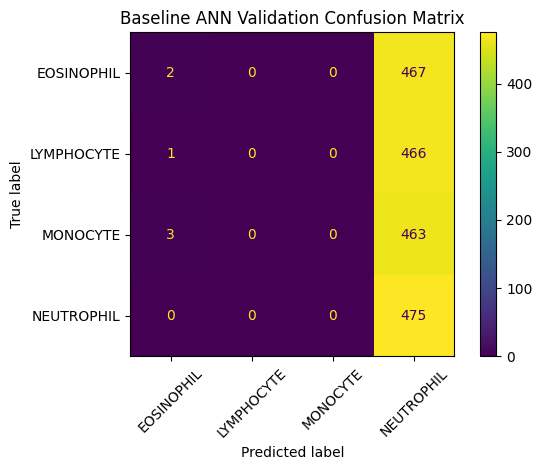

In [ ]:
cm = confusion_matrix(baseline_labels, baseline_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("Baseline ANN Validation Confusion Matrix")
plt.tight_layout()
plt.savefig("baseline_ann_confusion_matrix.png", dpi=300)
plt.show()

Custom CNN Model

In [ ]:
class BloodCellCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(BloodCellCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.dropout = nn.Dropout(p=0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # 64 x 64 -> 32 x 32
        x = self.pool(torch.relu(self.conv2(x)))  # 32 x 32 -> 16 x 16
        x = self.pool(torch.relu(self.conv3(x)))  # 16 x 16 -> 8 x 8

        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

cnn_model = BloodCellCNN(num_classes=4).to(device)

cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)

print(cnn_model)
print("Trainable parameters:", cnn_params)

BloodCellCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)
Trainable parameters: 548516


Trainn CNN

In [ ]:
CNN_EPOCHS = 8
LEARNING_RATE = 0.001

cnn_history = train_model(
    cnn_model,
    cnn_train_loader,
    cnn_val_loader,
    epochs=CNN_EPOCHS,
    learning_rate=LEARNING_RATE
)

Epoch 1/8 | Train Loss: 1.3545, Train Acc: 0.3094 | Val Loss: 1.1131, Val Acc: 0.5200
Epoch 2/8 | Train Loss: 0.8929, Train Acc: 0.6030 | Val Loss: 0.7430, Val Acc: 0.6830
Epoch 3/8 | Train Loss: 0.6448, Train Acc: 0.7183 | Val Loss: 0.5651, Val Acc: 0.7651
Epoch 4/8 | Train Loss: 0.5417, Train Acc: 0.7657 | Val Loss: 0.4940, Val Acc: 0.8077
Epoch 5/8 | Train Loss: 0.4422, Train Acc: 0.8173 | Val Loss: 0.3613, Val Acc: 0.8498
Epoch 6/8 | Train Loss: 0.3722, Train Acc: 0.8464 | Val Loss: 0.3800, Val Acc: 0.8316
Epoch 7/8 | Train Loss: 0.3138, Train Acc: 0.8748 | Val Loss: 0.2365, Val Acc: 0.9014
Epoch 8/8 | Train Loss: 0.2634, Train Acc: 0.8930 | Val Loss: 0.2339, Val Acc: 0.8950


CNN Learning Curves Plot

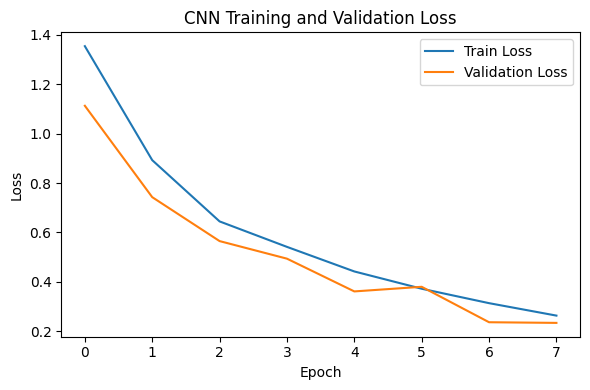

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(cnn_history["train_loss"], label="Train Loss")
plt.plot(cnn_history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("cnn_loss_curve.png", dpi=300)
plt.show()

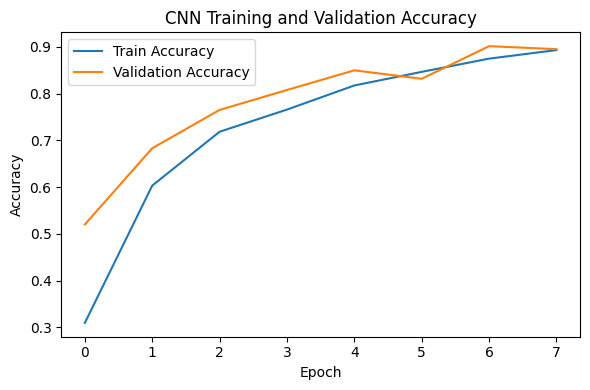

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(cnn_history["train_acc"], label="Train Accuracy")
plt.plot(cnn_history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("cnn_accuracy_curve.png", dpi=300)
plt.show()

CNN Validation Results

In [ ]:
cnn_val_loss, cnn_val_acc, cnn_preds, cnn_labels = evaluate_model(
    cnn_model,
    cnn_val_loader
)

cnn_macro_f1 = f1_score(cnn_labels, cnn_preds, average="macro")

print("CNN Validation Loss:", round(cnn_val_loss, 4))
print("CNN Validation Accuracy:", round(cnn_val_acc, 4))
print("CNN Macro F1:", round(cnn_macro_f1, 4))

print("\nClassification Report:")
print(classification_report(cnn_labels, cnn_preds, target_names=class_names))

CNN Validation Loss: 0.2339
CNN Validation Accuracy: 0.895
CNN Macro F1: 0.8945

Classification Report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.86      0.75      0.80       469
  LYMPHOCYTE       0.98      0.98      0.98       467
    MONOCYTE       0.95      1.00      0.97       466
  NEUTROPHIL       0.79      0.85      0.82       475

    accuracy                           0.90      1877
   macro avg       0.90      0.90      0.89      1877
weighted avg       0.90      0.90      0.89      1877



CNN Confusion Matrix

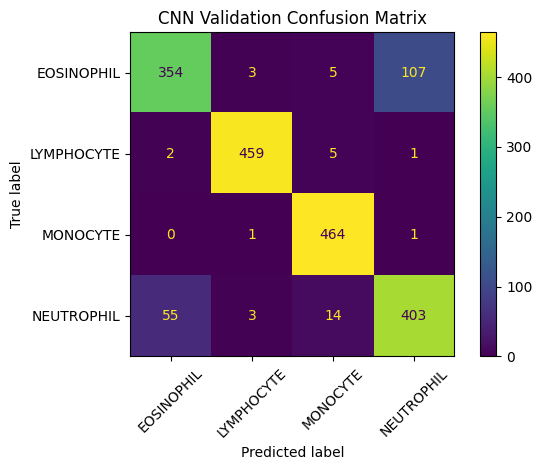

In [ ]:
cm = confusion_matrix(cnn_labels, cnn_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("CNN Validation Confusion Matrix")
plt.tight_layout()
plt.savefig("cnn_confusion_matrix.png", dpi=300)
plt.show()

CNN Qualitative Examples

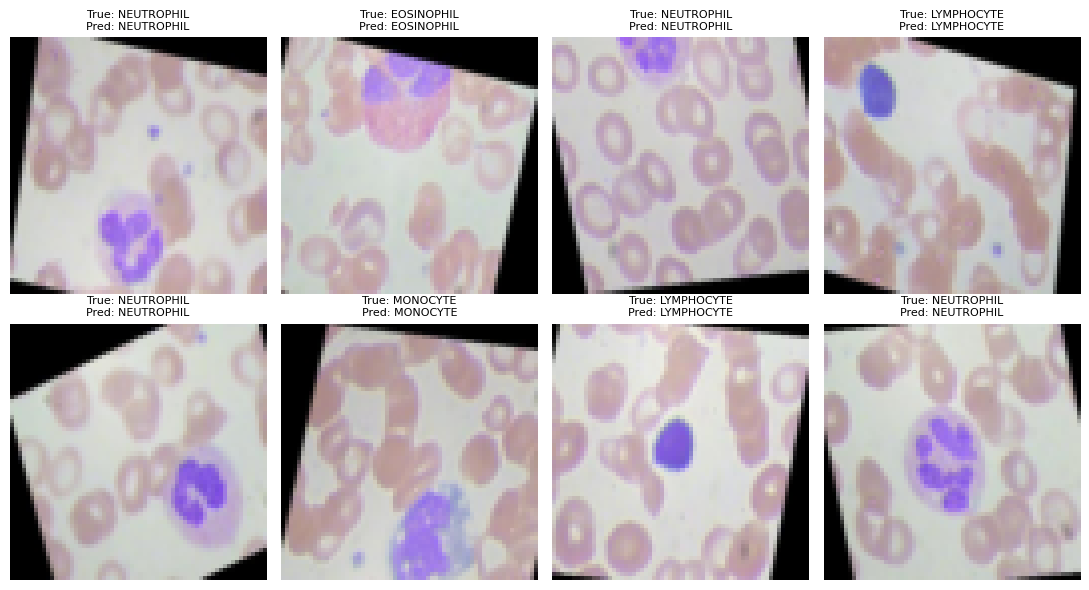

In [ ]:
def unnormalize_image(tensor_image):
    image = tensor_image.clone()
    image = image * 0.5 + 0.5
    image = image.permute(1, 2, 0).numpy()
    image = np.clip(image, 0, 1)
    return image


cnn_model.eval()

images_list = []
true_labels_list = []
pred_labels_list = []

with torch.no_grad():
    for images, labels in cnn_val_loader:
        images = images.to(device)
        outputs = cnn_model(images)
        predictions = torch.argmax(outputs, dim=1).cpu()

        for i in range(len(labels)):
            images_list.append(images[i].cpu())
            true_labels_list.append(labels[i].item())
            pred_labels_list.append(predictions[i].item())

        if len(images_list) >= 12:
            break

fig, axes = plt.subplots(2, 4, figsize=(11, 6))
axes = axes.flatten()

for i in range(8):
    axes[i].imshow(unnormalize_image(images_list[i]))

    true_label = idx_to_class[true_labels_list[i]]
    pred_label = idx_to_class[pred_labels_list[i]]

    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=8)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("cnn_qualitative_examples.png", dpi=300)
plt.show()

Comparing Baseline and CNN

In [ ]:
results_summary = pd.DataFrame({
    "Model": ["Baseline ANN", "Custom CNN"],
    "Validation Loss": [baseline_val_loss, cnn_val_loss],
    "Validation Accuracy": [baseline_val_acc, cnn_val_acc],
    "Validation Macro F1": [baseline_macro_f1, cnn_macro_f1],
    "Trainable Parameters": [baseline_params, cnn_params]
})

display(results_summary)

results_summary.to_csv("model_results_summary.csv", index=False)

,Model,Validation Loss,Validation Accuracy,Validation Macro F1,Trainable Parameters
0,Baseline ANN,1.386295,0.254129,0.103341,1573508
1,Custom CNN,0.233880,0.895045,0.894458,548516


Test Set Evaluation

In [ ]:
test_loss, test_acc, test_preds, test_labels = evaluate_model(
    cnn_model,
    test_loader
)

test_macro_f1 = f1_score(test_labels, test_preds, average="macro")

print("CNN Test Loss:", round(test_loss, 4))
print("CNN Test Accuracy:", round(test_acc, 4))
print("CNN Test Macro F1:", round(test_macro_f1, 4))

print("\nTest Classification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

CNN Test Loss: 0.2371
CNN Test Accuracy: 0.8998
CNN Test Macro F1: 0.8995

Test Classification Report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.88      0.77      0.82       470
  LYMPHOCYTE       0.97      0.98      0.97       466
    MONOCYTE       0.95      0.98      0.97       465
  NEUTROPHIL       0.81      0.87      0.84       476

    accuracy                           0.90      1877
   macro avg       0.90      0.90      0.90      1877
weighted avg       0.90      0.90      0.90      1877



FInal Report Summary

In [ ]:
print("DATA SUMMARY")
print("Total clean images:", len(clean_df))
print("\nClass split summary:")
display(split_summary)

print("\nBASELINE ANN SUMMARY")
print("Trainable parameters:", baseline_params)
print("Validation loss:", round(baseline_val_loss, 4))
print("Validation accuracy:", round(baseline_val_acc, 4))
print("Validation macro F1:", round(baseline_macro_f1, 4))

print("\nCNN SUMMARY")
print("Trainable parameters:", cnn_params)
print("Best validation accuracy:", round(max(cnn_history["val_acc"]), 4))
print("Final validation loss:", round(cnn_val_loss, 4))
print("Final validation accuracy:", round(cnn_val_acc, 4))
print("Final validation macro F1:", round(cnn_macro_f1, 4))

DATA SUMMARY
Total clean images: 12513

Class split summary:


,Train,Validation,Test,Total
label,,,,
EOSINOPHIL,2192,469,470,3131
LYMPHOCYTE,2176,467,466,3109
MONOCYTE,2171,466,465,3102
NEUTROPHIL,2220,475,476,3171



BASELINE ANN SUMMARY
Trainable parameters: 1573508
Validation loss: 1.3863
Validation accuracy: 0.2541
Validation macro F1: 0.1033

CNN SUMMARY
Trainable parameters: 548516
Best validation accuracy: 0.9014
Final validation loss: 0.2339
Final validation accuracy: 0.895
Final validation macro F1: 0.8945
